In [1]:
%run -i ../../python_scripts/nb_setup.py

GPU Available: False


#### Choose the dataset you want to use :
* must be data the model did not see at training
* first column : __y_true__ $\in \{0,1\}$ are the samples labels  
* second column : __y_pred__ are the predicted class of samples ($\in \{0,1\}$ too)
* third column : __kappa_f__ is confidence function for each sample, $\in \mathbb{R}$

In [2]:
sgp_df = pickle.load(open("sgp_set_resnet", "rb"))
print(
    "N =",
    sgp_df.shape[0],
    "Propotion of 1s: ",
    np.round(sgp_df.y_true.sum() / sgp_df.shape[0], 2),
)
sgp_df.head(3)

N = 40000 Propotion of 1s:  0.1


,y_true,y_pred,kappa
0,0.0,0.0,0.999986
1,0.0,0.0,0.999986
2,0.0,0.0,0.999990


In [3]:
num_targets = 50  # number of targets r* to consider when drawing metric/coverage of metric/theta curves
theta_min_SR, theta_max_SR = 0.5, 1  # Sn-independent grid

Plot lines config

In [4]:
lines_list_theta, lines_list_coverage, _, _, _ = lines()

## 1. __Unconditional risks__
Dichotomy search for upper bound

### 1.1. __0/1 risk__

In [5]:
# we restricted to [0.0001,0.02] after checking the bounds in joint_control_resnet.ipynb ; without prior knowledge just search over [0,1] with a higher num_targets
metric_targets = np.linspace(0.0001, 0.02, num=num_targets)

In [6]:
train_set, test_set = train_test_split(
    sgp_df, seed=8
)  # drawing 3/4 for bounds fitting, 1/4 for bounds testing
results = sgp_at_targets(
    train_set,
    test_set,
    metric_targets=metric_targets,
    mode="dicho",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

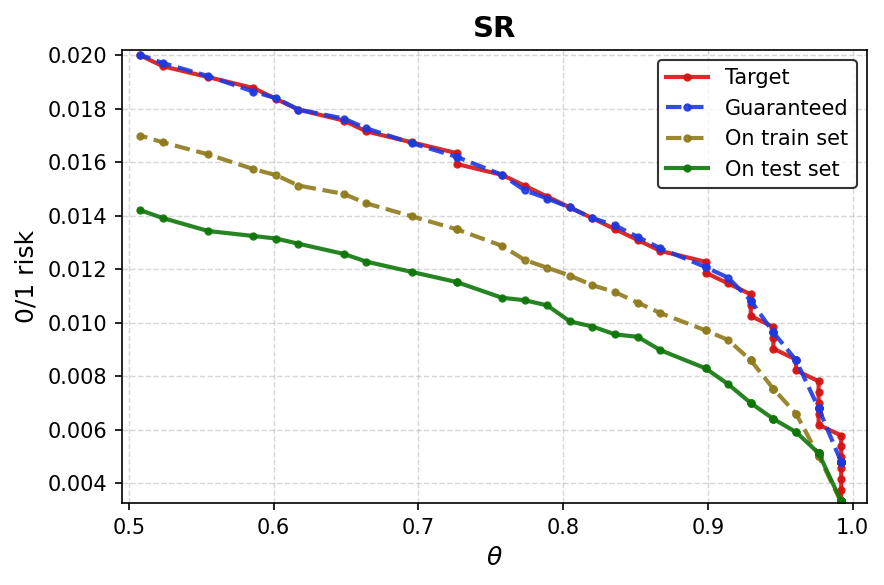

In [7]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_theta,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

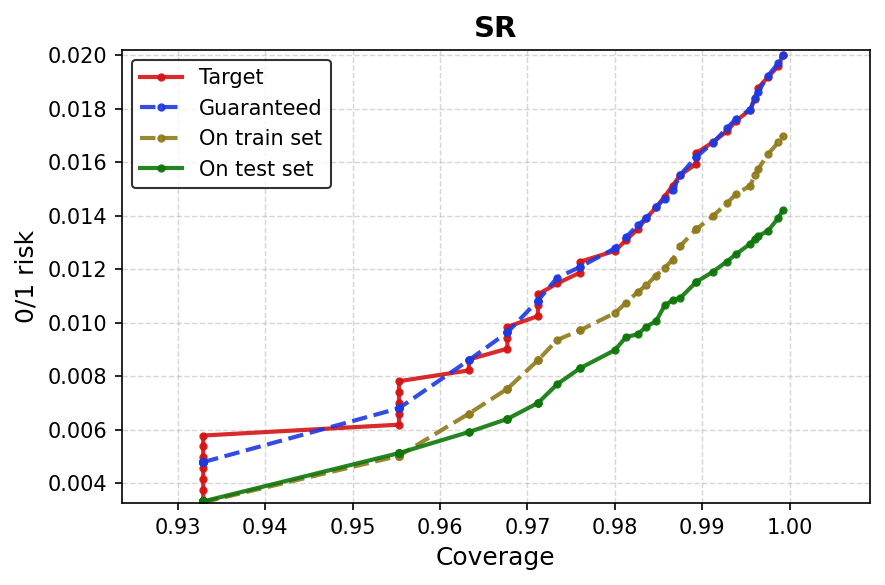

In [8]:
metric_plots(
    all_results,
    metric="0/1 risk",
    lines_list=lines_list_coverage,
    xlim=[0.99 * min(results.test_coverage), 1.01 * max(results.test_coverage)],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

### 1.2. __FP risk__

In [9]:
metric_targets = np.linspace(0.0001, 0.0035, num=num_targets)

In [10]:
train_set, test_set = train_test_split(sgp_df, seed=9)
results = sgp_at_targets(
    train_set,
    test_set,
    metric_targets=metric_targets,
    mode="dicho",
    metric="FP",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

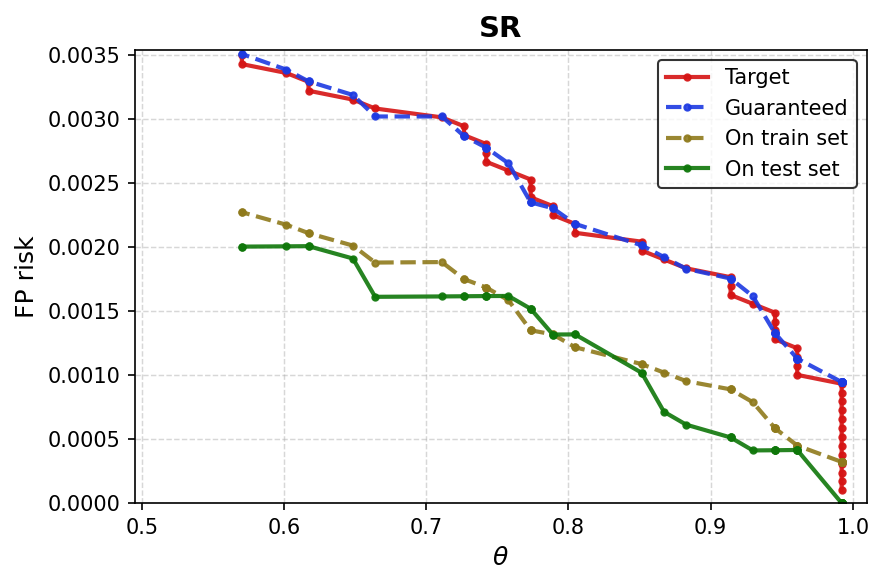

In [11]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_theta,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

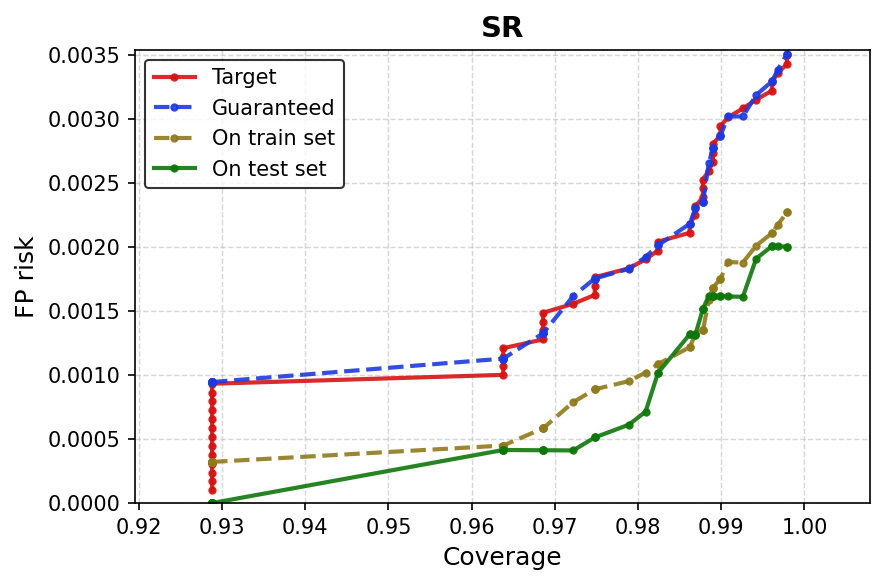

In [12]:
metric_plots(
    all_results,
    metric="FP risk",
    lines_list=lines_list_coverage,
    xlim=[0.99 * min(results.test_coverage), 1.01 * max(results.test_coverage)],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

### 1.3. __FN risk__

In [13]:
metric_targets = np.linspace(0.0001, 0.025, num=num_targets)

In [14]:
train_set, test_set = train_test_split(sgp_df, seed=10)
results = sgp_at_targets(
    train_set,
    test_set,
    metric_targets=metric_targets,
    mode="dicho",
    metric="FN",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

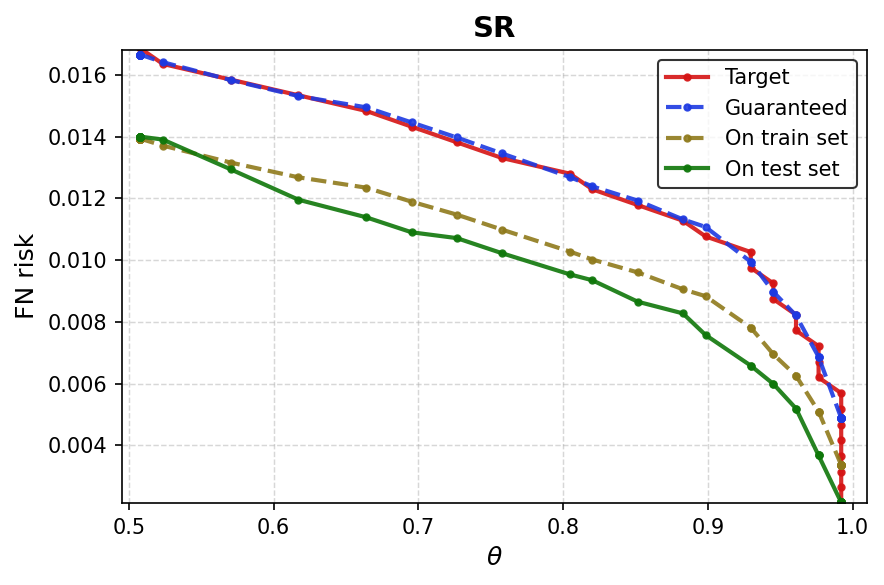

In [15]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_theta,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

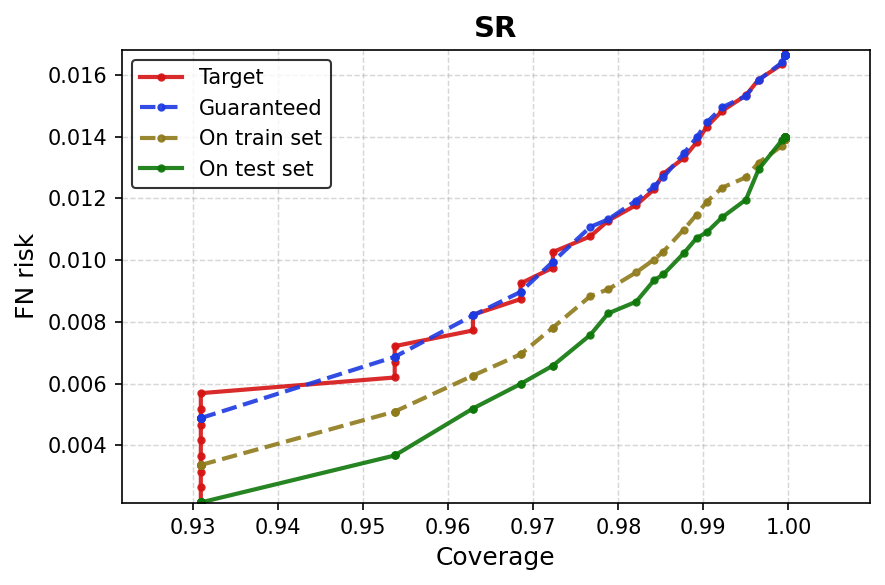

In [16]:
metric_plots(
    all_results,
    metric="FN risk",
    lines_list=lines_list_coverage,
    xlim=[0.99 * min(results.test_coverage), 1.01 * max(results.test_coverage)],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

## __2. Conditional metrics__
Greedy search for the bounds

### 2.1. __FPR__

In [17]:
metric_targets = np.linspace(0.0001, 0.0035, num=num_targets)

In [18]:
train_set, test_set = train_test_split(sgp_df, seed=11)
results = sgp_at_targets(
    train_set,
    test_set,
    metric_targets=metric_targets,
    mode="greedy",
    metric="FPR",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

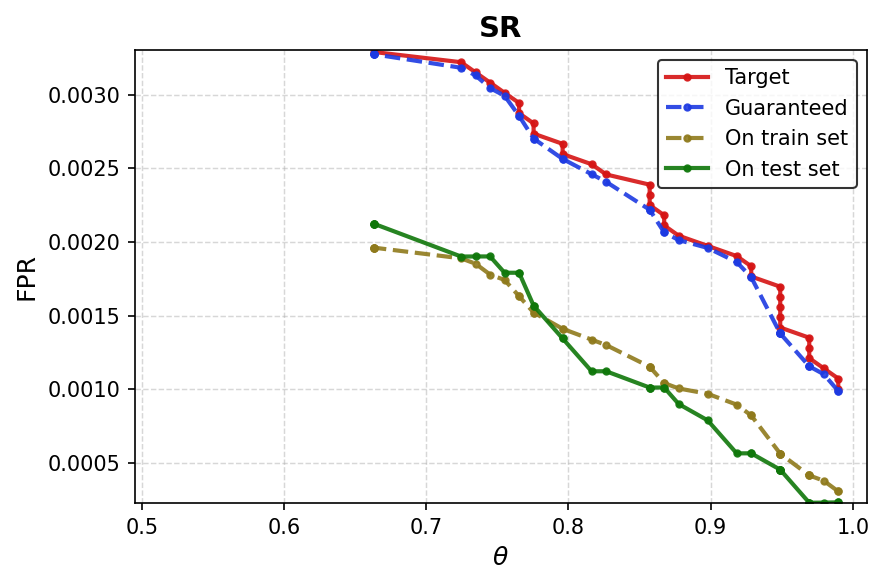

In [19]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_theta,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

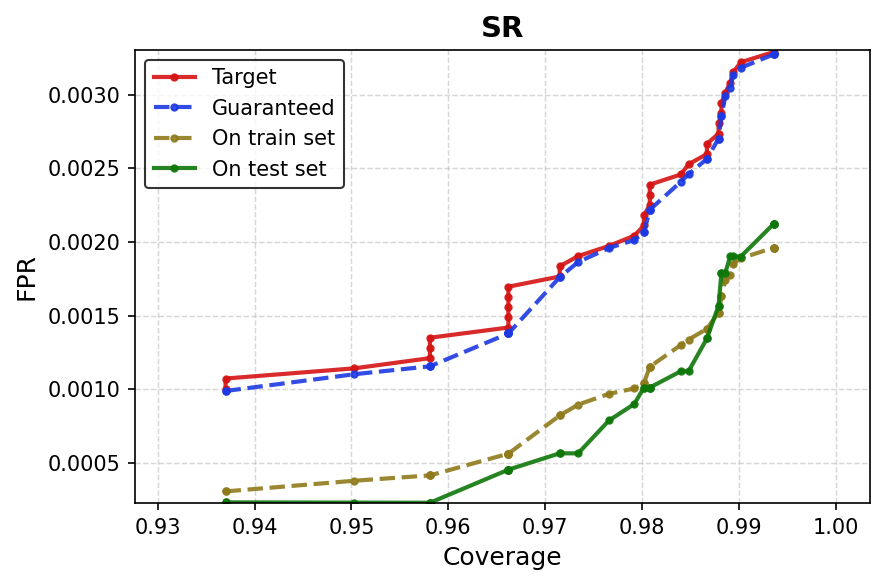

In [20]:
metric_plots(
    all_results,
    metric="FPR",
    lines_list=lines_list_coverage,
    xlim=[0.99 * min(results.test_coverage), 1.01 * max(results.test_coverage)],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

### 2.2. __FNR__

In [21]:
metric_targets = np.linspace(0.03, 0.2, num=num_targets)

In [22]:
train_set, test_set = train_test_split(sgp_df, seed=12)
results = sgp_at_targets(
    train_set,
    test_set,
    metric_targets=metric_targets,
    mode="greedy",
    metric="FNR",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

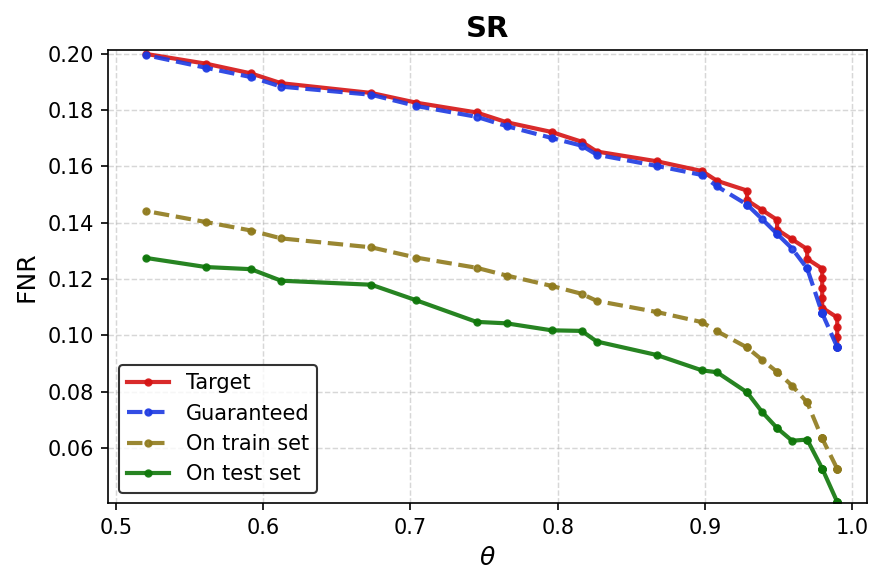

In [23]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_theta,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

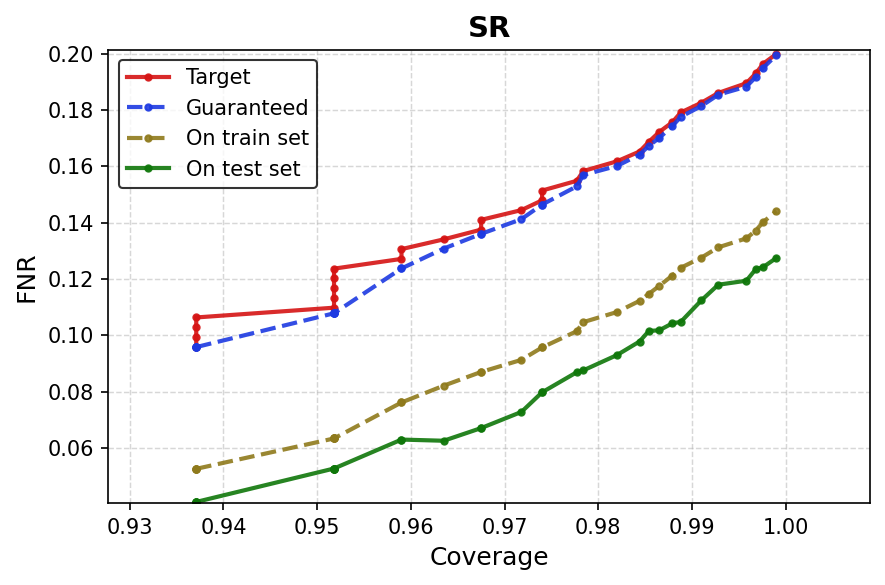

In [24]:
metric_plots(
    all_results,
    metric="FNR",
    lines_list=lines_list_coverage,
    xlim=[0.99 * min(results.test_coverage), 1.01 * max(results.test_coverage)],
    ylim=[
        0.99 * min(min(results.test_metric), min(results.train_metric)),
        1.01 * max(results.metric_bound),
    ],
    title="SR",
)

### 2.3. __PPV__

In [25]:
metric_targets = np.linspace(0.95, 0.999, num=num_targets)

In [26]:
train_set, test_set = train_test_split(sgp_df, seed=13)
results = sgp_at_targets(
    train_set,
    test_set,
    metric_targets=metric_targets,
    mode="greedy",
    metric="PPV",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

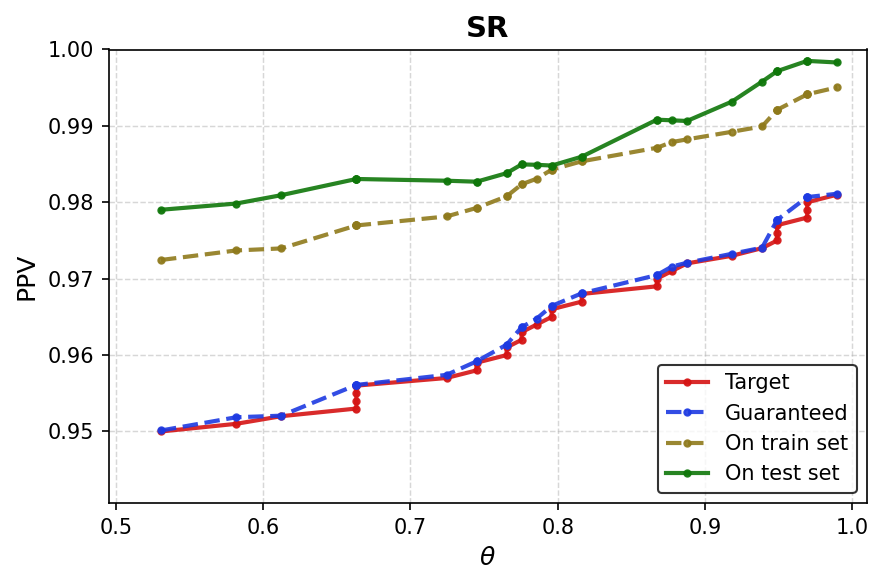

In [27]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_theta,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results.metric_bound),
        min(1, 1.01 * max(max(results.train_metric), max(results.test_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

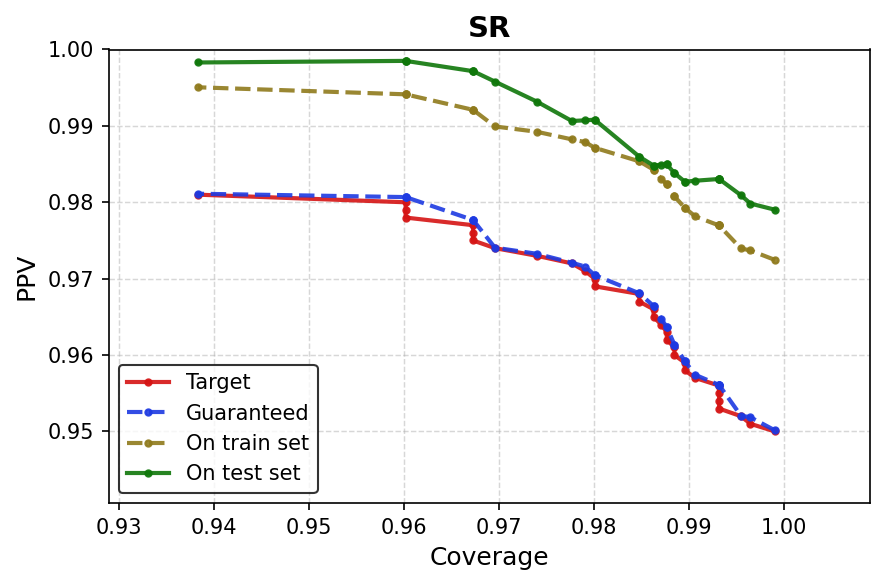

In [28]:
metric_plots(
    all_results,
    metric="PPV",
    lines_list=lines_list_coverage,
    xlim=[0.99 * min(results.test_coverage), 1.01 * max(results.test_coverage)],
    ylim=[
        0.99 * min(results.metric_bound),
        min(1, 1.01 * max(max(results.train_metric), max(results.test_metric))),
    ],
    title="SR",
)

### 2.4. __SE__

In [29]:
metric_targets = np.linspace(0.84, 0.96, num=num_targets)

In [30]:
train_set, test_set = train_test_split(sgp_df, seed=14)
results = sgp_at_targets(
    train_set,
    test_set,
    metric_targets=metric_targets,
    mode="greedy",
    metric="SE",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

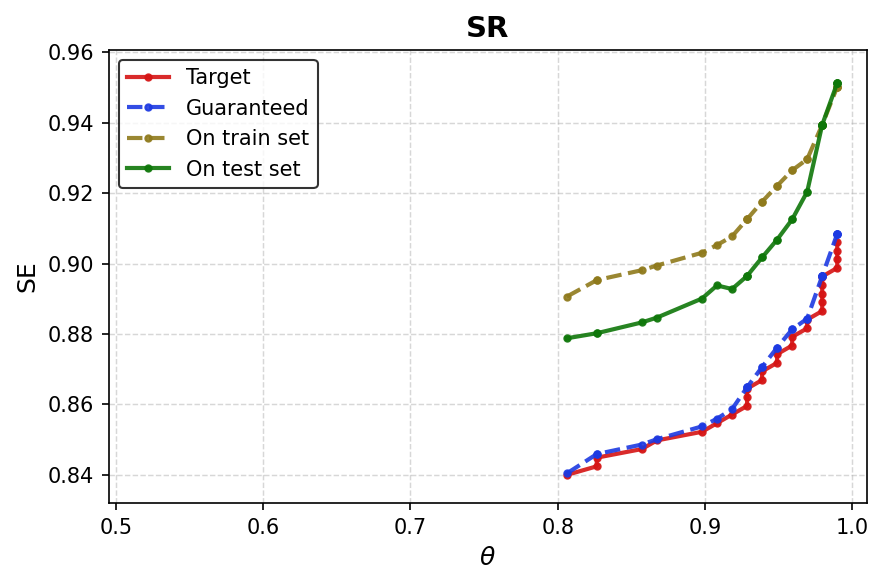

In [31]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_theta,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results.metric_bound),
        min(1, 1.01 * max(max(results.train_metric), max(results.test_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

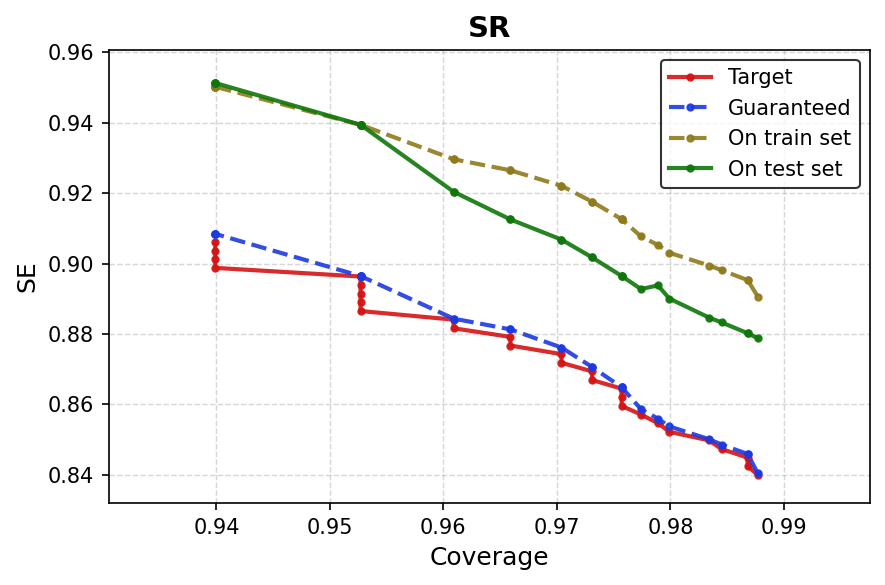

In [32]:
metric_plots(
    all_results,
    metric="SE",
    lines_list=lines_list_coverage,
    xlim=[0.99 * min(results.test_coverage), 1.01 * max(results.test_coverage)],
    ylim=[
        0.99 * min(results.metric_bound),
        min(1, 1.01 * max(max(results.train_metric), max(results.test_metric))),
    ],
    title="SR",
)

### 2.5. __SP__

In [33]:
metric_targets = np.linspace(0.99, 0.9999, num=num_targets)

In [34]:
train_set, test_set = train_test_split(sgp_df, seed=15)
results = sgp_at_targets(
    train_set,
    test_set,
    metric_targets=metric_targets,
    mode="greedy",
    metric="SP",
    theta_min=theta_min_SR,
    theta_max=theta_max_SR,
)
all_results = {"SR": results, "MCD": None}

Curves w.r.t. $\theta$, using Softmax Response (SR) as confidence function

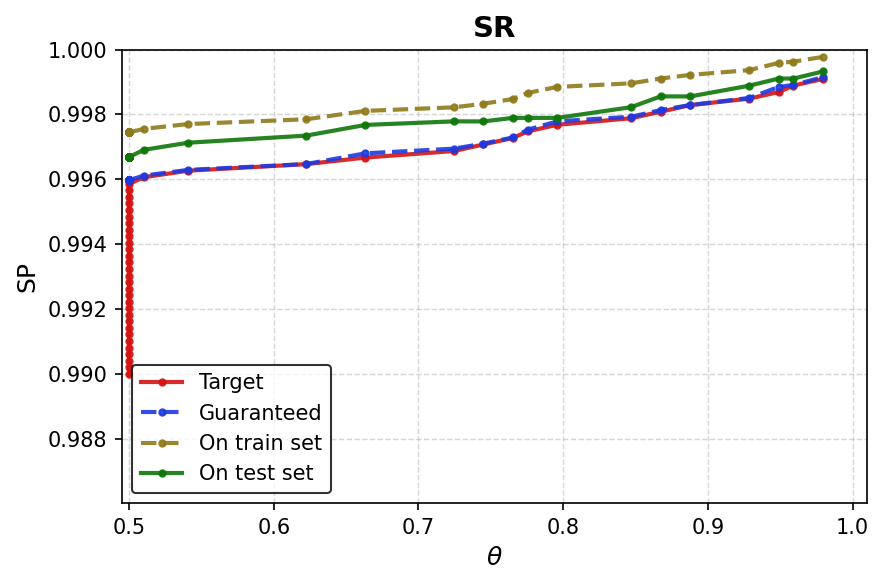

In [35]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_theta,
    xlim=[0.99 * theta_min_SR, 1.01 * theta_max_SR],
    ylim=[
        0.99 * min(results.metric_bound),
        min(1, 1.01 * max(max(results.train_metric), max(results.test_metric))),
    ],
    title="SR",
)

Curves w.r.t. coverage, using Softmax Response (SR) as confidence function

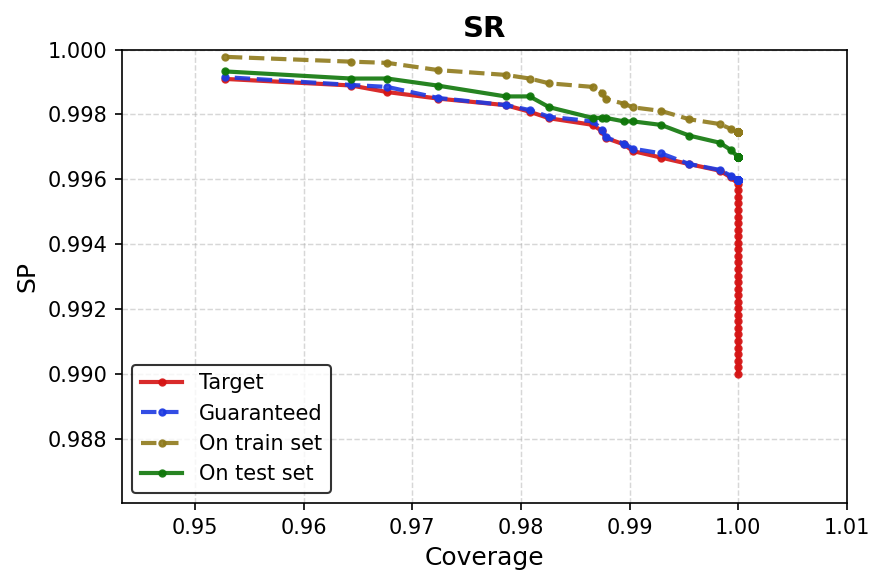

In [36]:
metric_plots(
    all_results,
    metric="SP",
    lines_list=lines_list_coverage,
    xlim=[0.99 * min(results.test_coverage), 1.01 * max(results.test_coverage)],
    ylim=[
        0.99 * min(results.metric_bound),
        min(1, 1.01 * max(max(results.train_metric), max(results.test_metric))),
    ],
    title="SR",
)